In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import warnings

warnings.filterwarnings("ignore")

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [ ]:
# Load the data from CSV file
df = pd.read_csv("synthetic_datacenter_energy_data.csv")

# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Handle is_weekend column - convert to numeric (Data preprocessing)
if df["is_weekend"].dtype == "object" or df["is_weekend"].dtype == "bool":
    df["is_weekend"] = df["is_weekend"].map({True: 1, False: 0, "True": 1, "False": 0})

# Check for missing values and handle them
print("\nChecking for missing values...")
missing_before = df.isnull().sum()
if missing_before.sum() > 0:
    print("Missing values found:")
    print(missing_before[missing_before > 0])
    print("\nImputing missing values with column means...")
    df = df.fillna(df.mean(numeric_only=True))
else:
    print("No missing values found.")

print("=" * 80)
print("DATACENTER ENERGY FORECASTING - EXPLORATORY DATA ANALYSIS")
print("=" * 80)



Checking for missing values...
No missing values found.
DATACENTER ENERGY FORECASTING - EXPLORATORY DATA ANALYSIS


In [21]:
# ============================================================================
# 1. BASIC DATA OVERVIEW
# ============================================================================
print("\n1. DATASET OVERVIEW")
print("-" * 80)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\nBasic statistics:")
print(df.describe())



1. DATASET OVERVIEW
--------------------------------------------------------------------------------
Dataset shape: (8784, 10)

First few rows:
            timestamp  hour  day_of_week  is_weekend  outside_temp_c  \
0 2024-01-01 00:00:00     0            0           0       10.993428   
1 2024-01-01 01:00:00     1            0           0        9.730644   
2 2024-01-01 02:00:00     2            0           0       11.309722   
3 2024-01-01 03:00:00     3            0           0       13.067577   
4 2024-01-01 04:00:00     4            0           0        9.560384   

   avg_cpu_utilization  active_servers  it_power_kw  cooling_power_kw  \
0             0.289804             845   393.703859        118.111158   
1             0.361263             860   425.274415        127.582324   
2             0.381468             976   490.525120        147.157536   
3             0.335047             884   427.872459        128.361738   
4             0.383965             909   457.759562      


2. EXPLORATORY DATA ANALYSIS - VISUALIZATIONS

✓ Saved: 1_feature_distributions.png


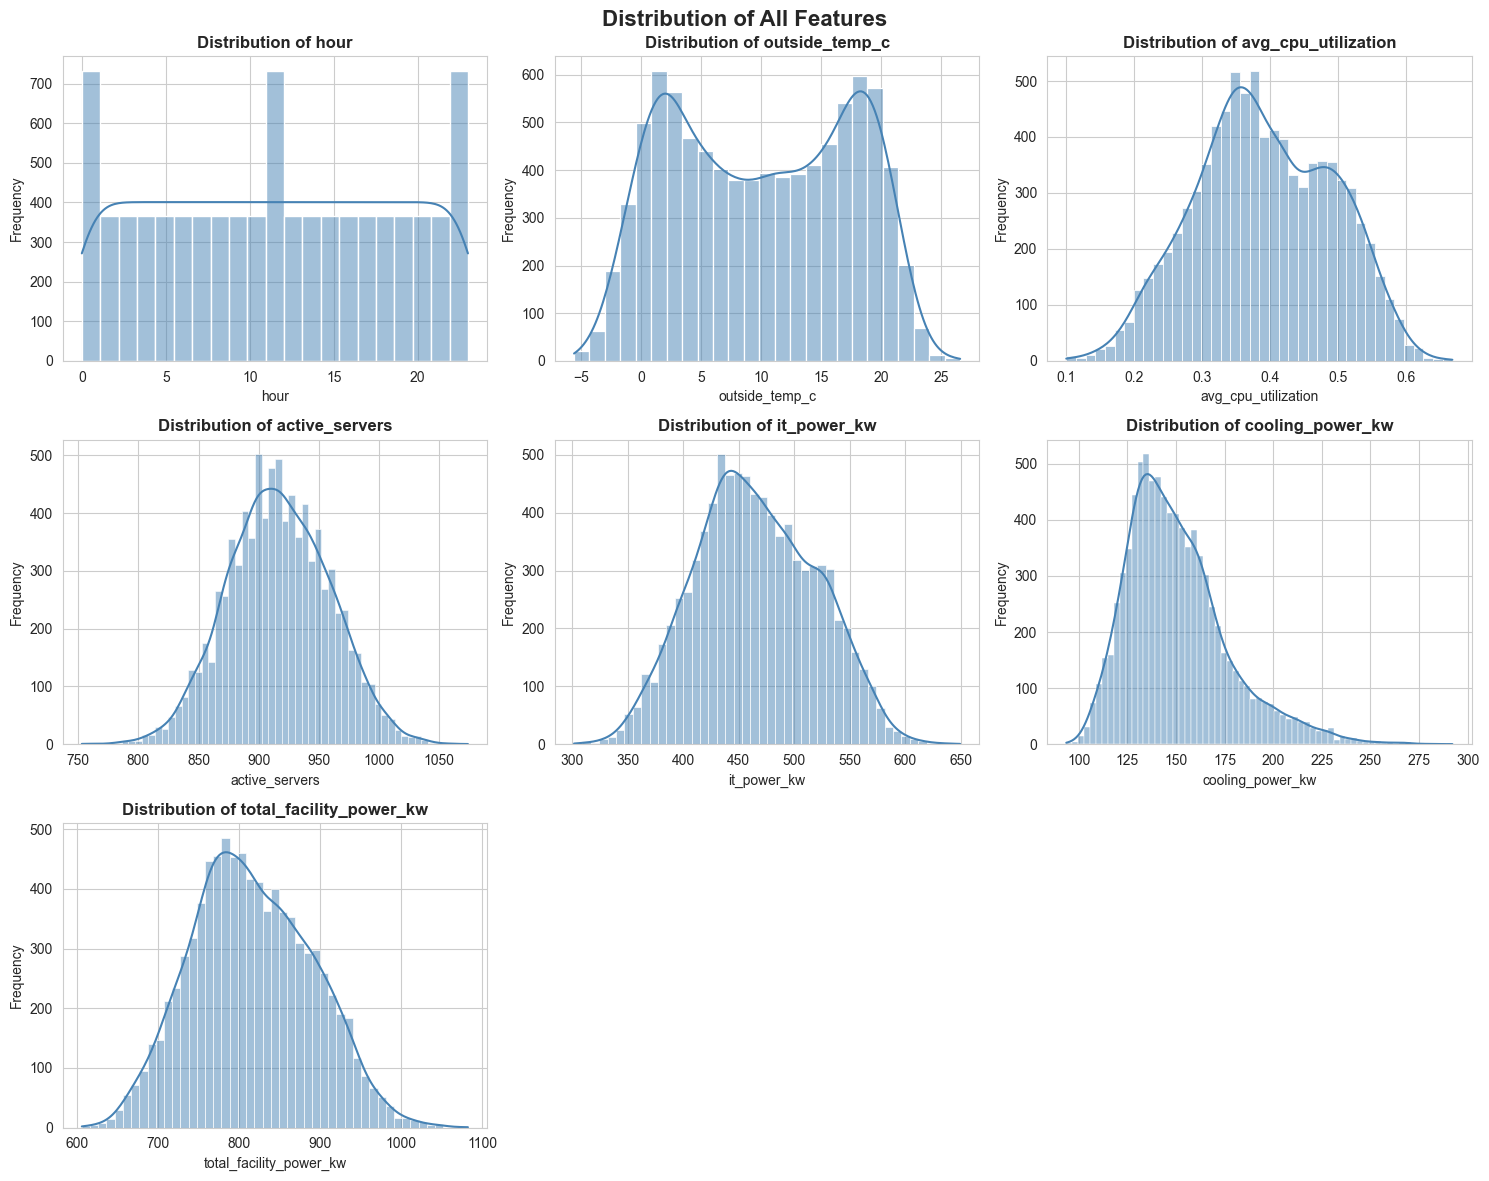

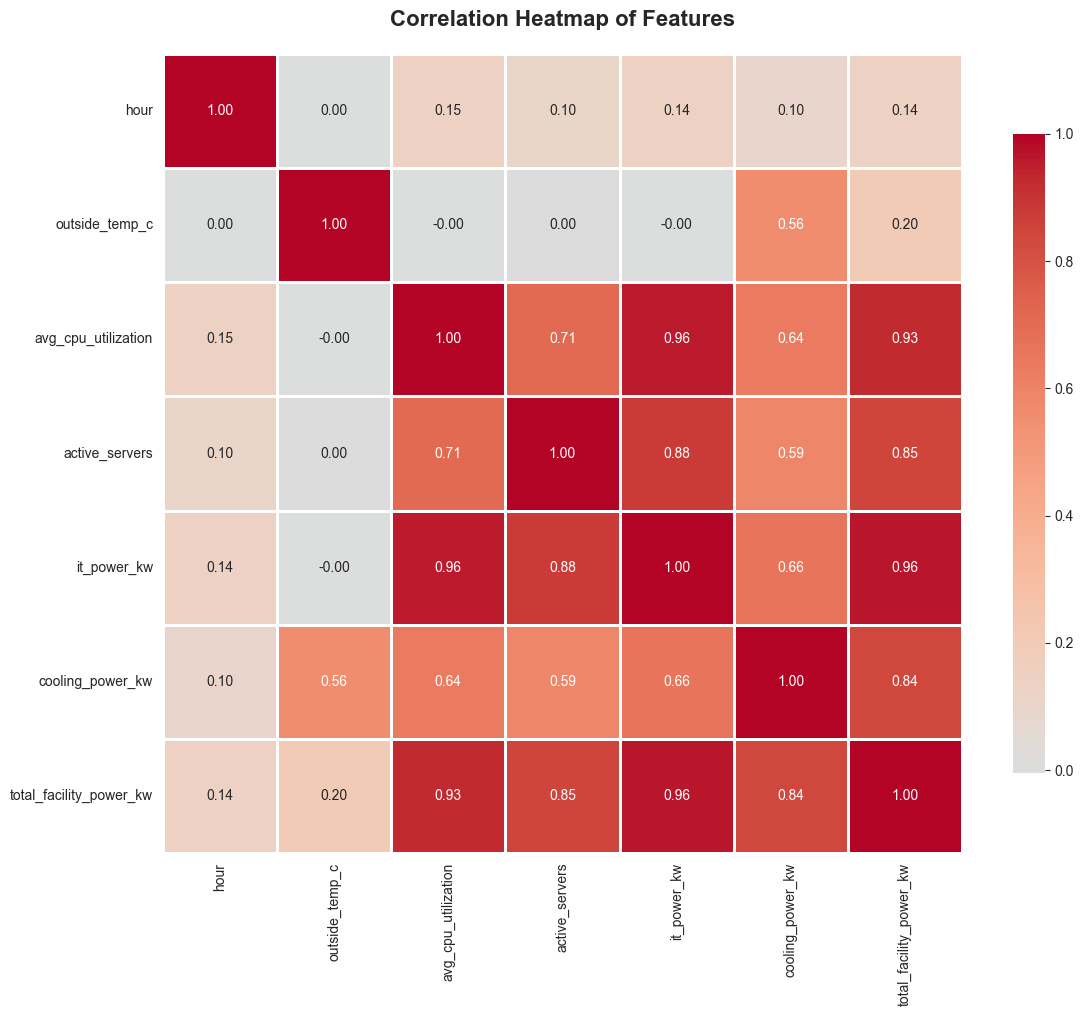

In [ ]:
# ============================================================================
# 2. EXPLORATORY DATA ANALYSIS WITH VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 80)
print("2. EXPLORATORY DATA ANALYSIS - VISUALIZATIONS")
print("=" * 80)

# Figure 1: Distribution of all numerical features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Distribution of All Features", fontsize=16, fontweight="bold")

numerical_cols = [
    "hour",
    "outside_temp_c",
    "avg_cpu_utilization",
    "active_servers",
    "it_power_kw",
    "cooling_power_kw",
    "total_facility_power_kw",
]

for idx, col in enumerate(numerical_cols):
    row = idx // 3
    col_idx = idx % 3
    sns.histplot(df[col], kde=True, ax=axes[row, col_idx], color="steelblue")
    axes[row, col_idx].set_title(f"Distribution of {col}", fontweight="bold")
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel("Frequency")

# Remove extra subplots
for idx in range(len(numerical_cols), 9):
    fig.delaxes(axes[idx // 3, idx % 3])

plt.tight_layout()


# Figure 2: Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap of Features", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()


### Avg cpu , active server , it power and cooling the major Features for the total facility power consumption

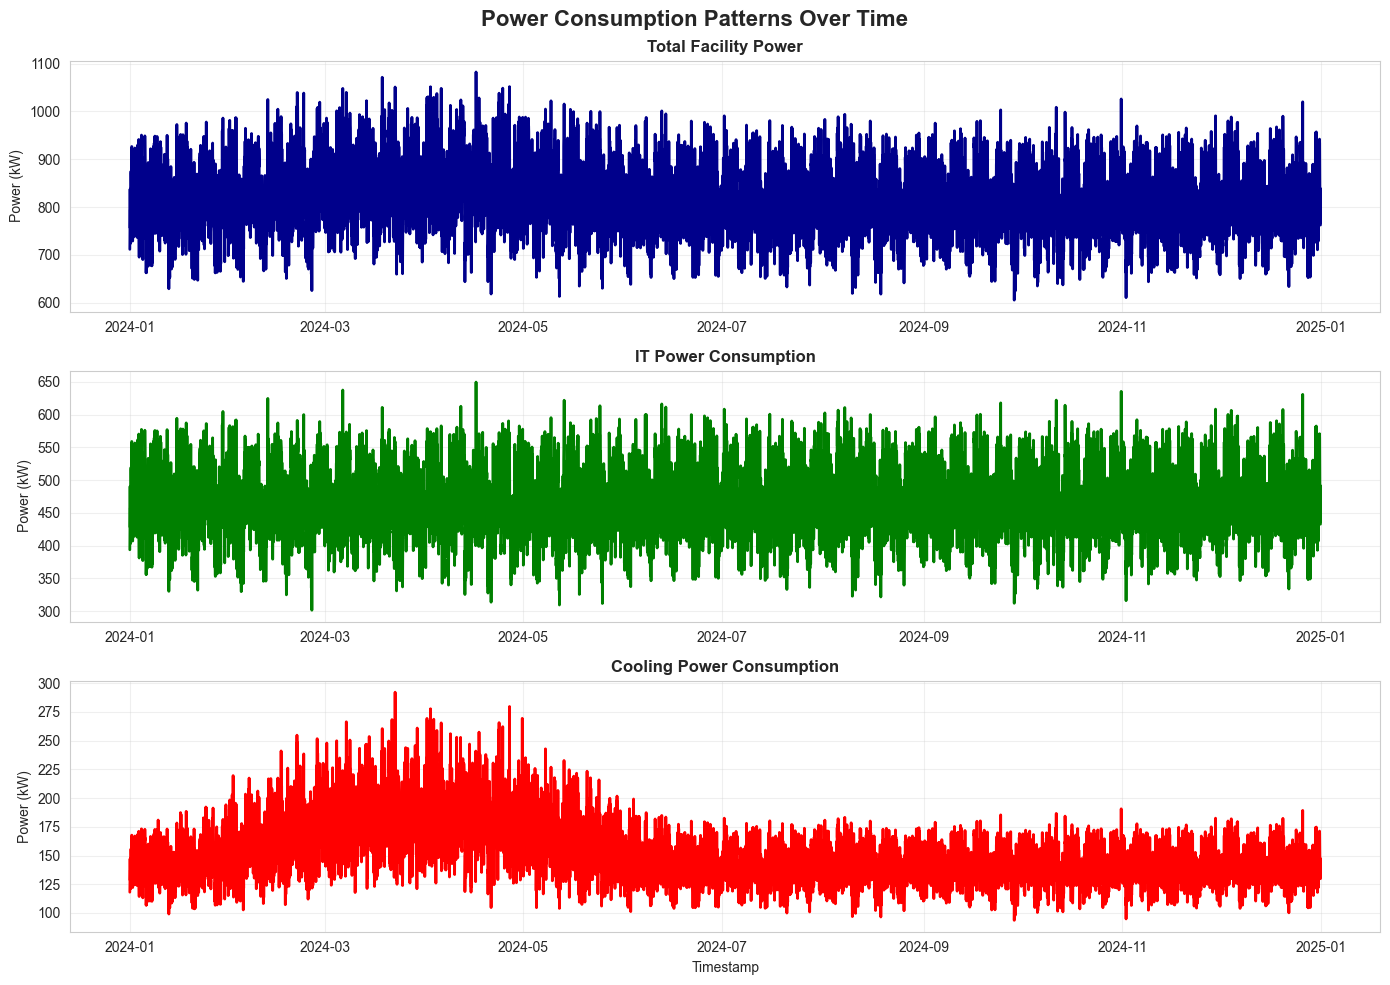

In [23]:
# Figure 3: Power Consumption Over Time
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Power Consumption Patterns Over Time", fontsize=16, fontweight="bold")

axes[0].plot(
    df["timestamp"], df["total_facility_power_kw"], color="darkblue", linewidth=2
)
axes[0].set_title("Total Facility Power", fontweight="bold")
axes[0].set_ylabel("Power (kW)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["timestamp"], df["it_power_kw"], color="green", linewidth=2)
axes[1].set_title("IT Power Consumption", fontweight="bold")
axes[1].set_ylabel("Power (kW)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(df["timestamp"], df["cooling_power_kw"], color="red", linewidth=2)
axes[2].set_title("Cooling Power Consumption", fontweight="bold")
axes[2].set_ylabel("Power (kW)")
axes[2].set_xlabel("Timestamp")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()


### Observation more power needed on the first couple of months for cooling

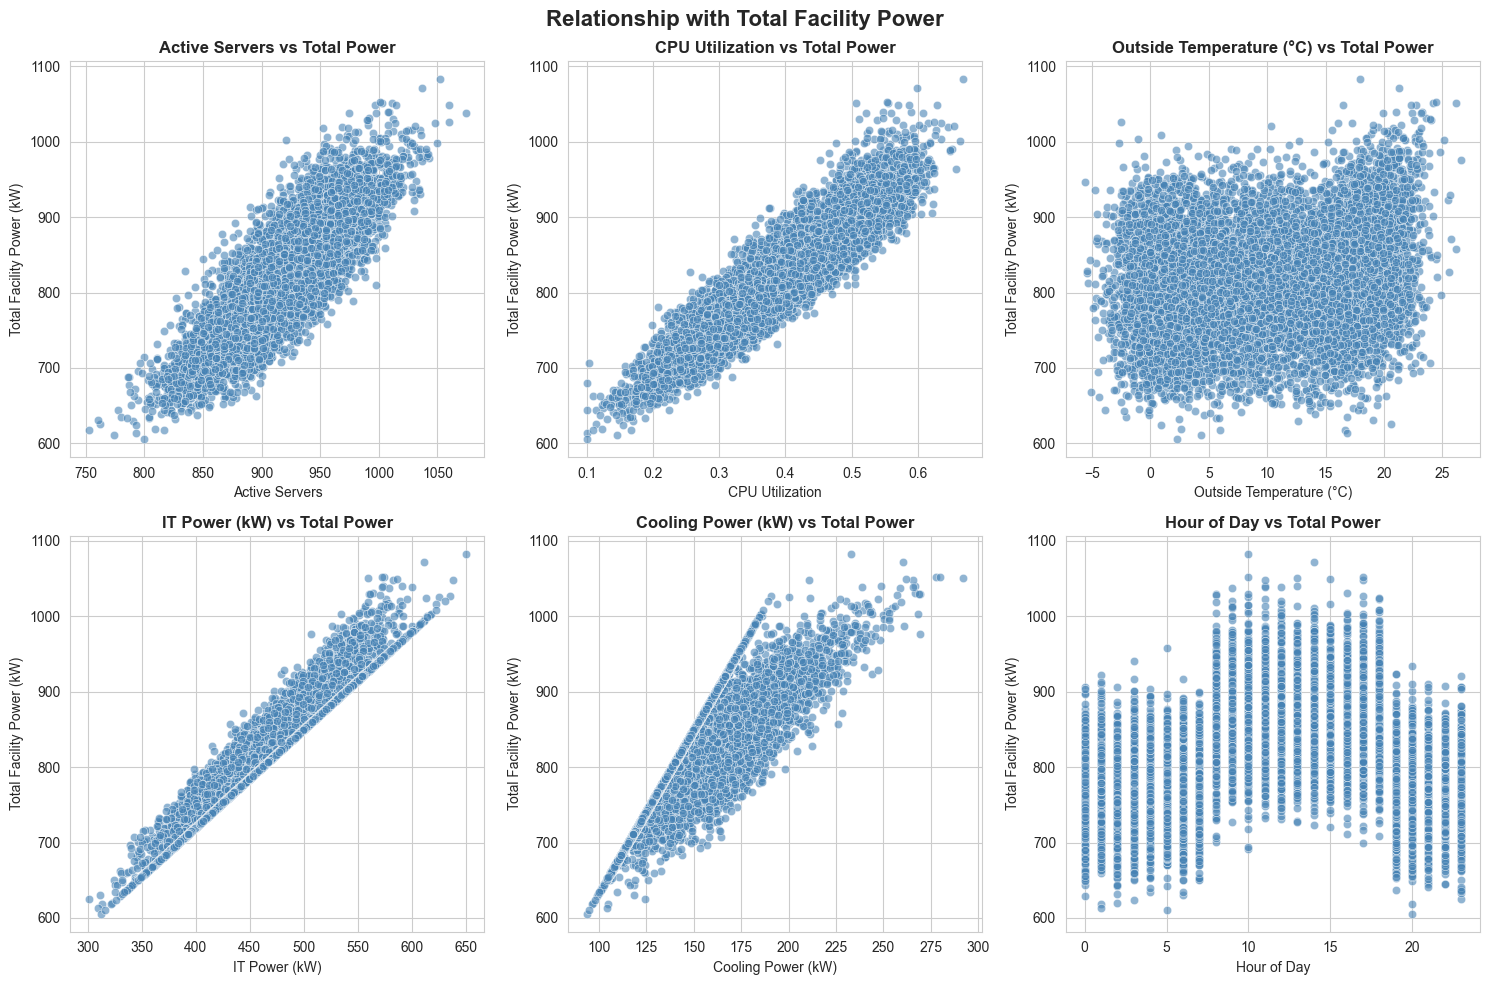

In [24]:
# Figure 4: Relationships with Target Variable
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Relationship with Total Facility Power", fontsize=16, fontweight="bold")

feature_pairs = [
    ("active_servers", "Active Servers"),
    ("avg_cpu_utilization", "CPU Utilization"),
    ("outside_temp_c", "Outside Temperature (°C)"),
    ("it_power_kw", "IT Power (kW)"),
    ("cooling_power_kw", "Cooling Power (kW)"),
    ("hour", "Hour of Day"),
]

for idx, (feature, title) in enumerate(feature_pairs):
    row = idx // 3
    col = idx % 3
    sns.scatterplot(
        data=df,
        x=feature,
        y="total_facility_power_kw",
        ax=axes[row, col],
        alpha=0.6,
        color="steelblue",
    )
    axes[row, col].set_title(f"{title} vs Total Power", fontweight="bold")
    axes[row, col].set_xlabel(title)
    axes[row, col].set_ylabel("Total Facility Power (kW)")

plt.tight_layout()


### Most features follow the same upwards pattern . Also outside temperature affects the total power consumption when its too high (probably more cooling power is needed) 

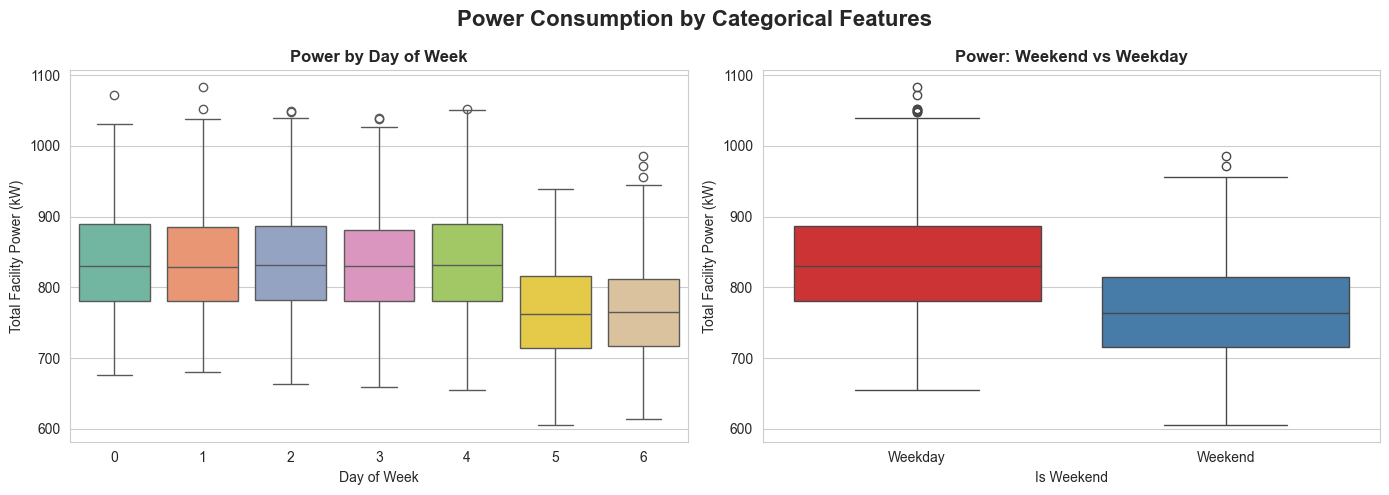

In [25]:
# Figure 5: Box plots for categorical features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Power Consumption by Categorical Features", fontsize=16, fontweight="bold"
)

sns.boxplot(
    data=df, x="day_of_week", y="total_facility_power_kw", ax=axes[0], palette="Set2"
)
axes[0].set_title("Power by Day of Week", fontweight="bold")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Total Facility Power (kW)")

sns.boxplot(
    data=df, x="is_weekend", y="total_facility_power_kw", ax=axes[1], palette="Set1"
)
axes[1].set_title("Power: Weekend vs Weekday", fontweight="bold")
axes[1].set_xlabel("Is Weekend")
axes[1].set_ylabel("Total Facility Power (kW)")
axes[1].set_xticklabels(["Weekday", "Weekend"])

plt.tight_layout()



### More power needed on Weekdays

Text(0.5, 1.02, 'Pairplot of Key Features')

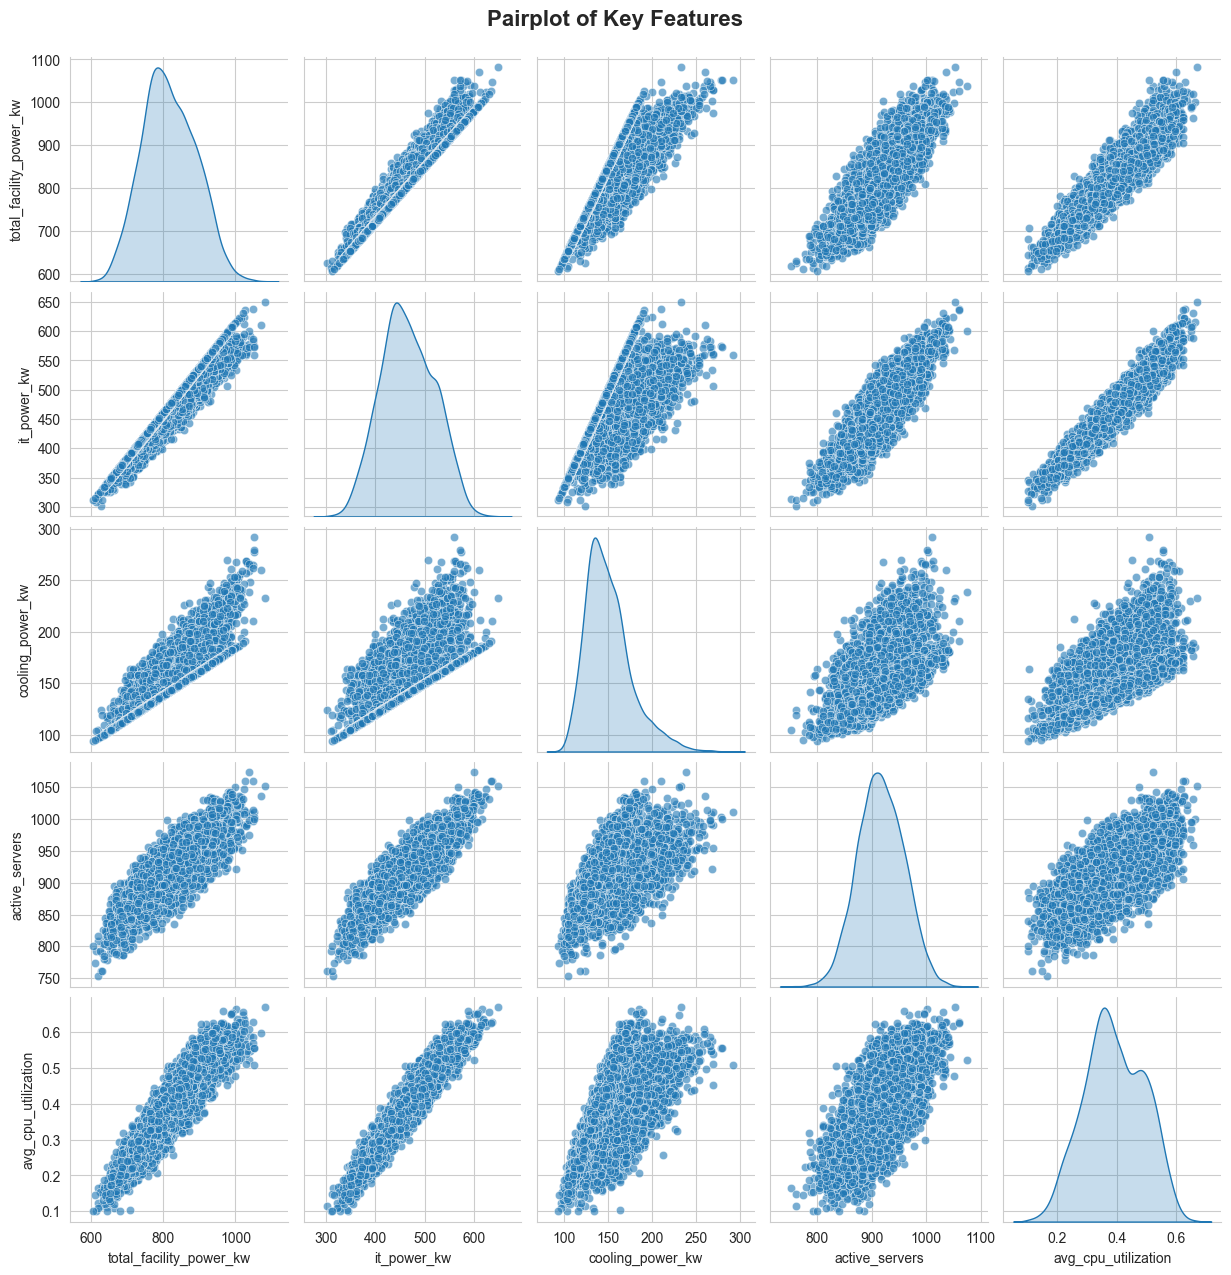

In [26]:
# Figure 6: Pairplot for key features
key_features = [
    "total_facility_power_kw",
    "it_power_kw",
    "cooling_power_kw",
    "active_servers",
    "avg_cpu_utilization",
]
pairplot = sns.pairplot(df[key_features], diag_kind="kde", plot_kws={"alpha": 0.6})
pairplot.fig.suptitle(
    "Pairplot of Key Features", y=1.02, fontsize=16, fontweight="bold"
)



### Same upwards pattern for the 4 most weighted feutures in dataset, avg_cpu_utilization , active server count , cooling power , it power.

In [27]:
# ============================================================================
# 3. FEATURE ENGINEERING & MODEL TRAINING
# ============================================================================
print("\n" + "=" * 80)
print("3. MACHINE LEARNING MODEL TRAINING")
print("=" * 80)

# Prepare features and target
feature_cols = [
    "hour",
    "day_of_week",
    "is_weekend",
    "outside_temp_c",
    "avg_cpu_utilization",
    "active_servers",
    "it_power_kw",
    "cooling_power_kw",
]
X = df[feature_cols].copy()
y = df["total_facility_power_kw"].copy()

# Double-check for any remaining NaN values
print(f"\nChecking features for NaN values:")
print(f"NaN in X: {X.isnull().sum().sum()}")
print(f"NaN in y: {y.isnull().sum()}")




3. MACHINE LEARNING MODEL TRAINING

Checking features for NaN values:
NaN in X: 0
NaN in y: 0


In [ ]:
# Remove any rows with NaN values if they still exist (should be none after imputation)
if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("\nRemoving rows with NaN values...")
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[mask]
    y = y[mask]
    print(f"Remaining samples: {len(X)}")


In [29]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")



Training set size: 7027
Test set size: 1757


In [ ]:
# Train multiple models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, random_state=42, max_depth=10
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, random_state=42, max_depth=5
    ),
}

results = {}

In [ ]:
print("\n" + "-" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("-" * 80)

for name, model in models.items():
    # Train model
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    results[name] = {
        "model": model,
        "predictions": y_pred,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape,
    }

    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.2f} kW")
    print(f"  MAE:  {mae:.2f} kW")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

# Select best model (Random Forest typically performs well)
best_model_name = "Random Forest"
best_model = results[best_model_name]["model"]
best_predictions = results[best_model_name]["predictions"]



--------------------------------------------------------------------------------
MODEL PERFORMANCE COMPARISON
--------------------------------------------------------------------------------

Linear Regression:
  RMSE: 0.00 kW
  MAE:  0.00 kW
  R²:   1.0000
  MAPE: 0.00%

Random Forest:
  RMSE: 2.00 kW
  MAE:  0.59 kW
  R²:   0.9993
  MAPE: 0.07%

Gradient Boosting:
  RMSE: 1.68 kW
  MAE:  0.88 kW
  R²:   0.9995
  MAPE: 0.10%


### The Metric Definitions
#### RMSE (Root Mean Squared Error): This penalizes large errors. An RMSE of 2.00 kW means that, on average, the model's prediction is off by about 2 kW.

#### MAE (Mean Absolute Error): The average of all absolute errors. Random Forest is off by only 0.59 kW on average, which is tiny compared to a ~800 kW load.

#### R² (R-Squared): This represents the "Goodness of Fit." A value of 1.00 means the model explains 100% of the variance in the data.

#### MAPE (Mean Absolute Percentage Error): The error expressed as a percentage. Errors are less than 0.1%, which is near-perfect precision.

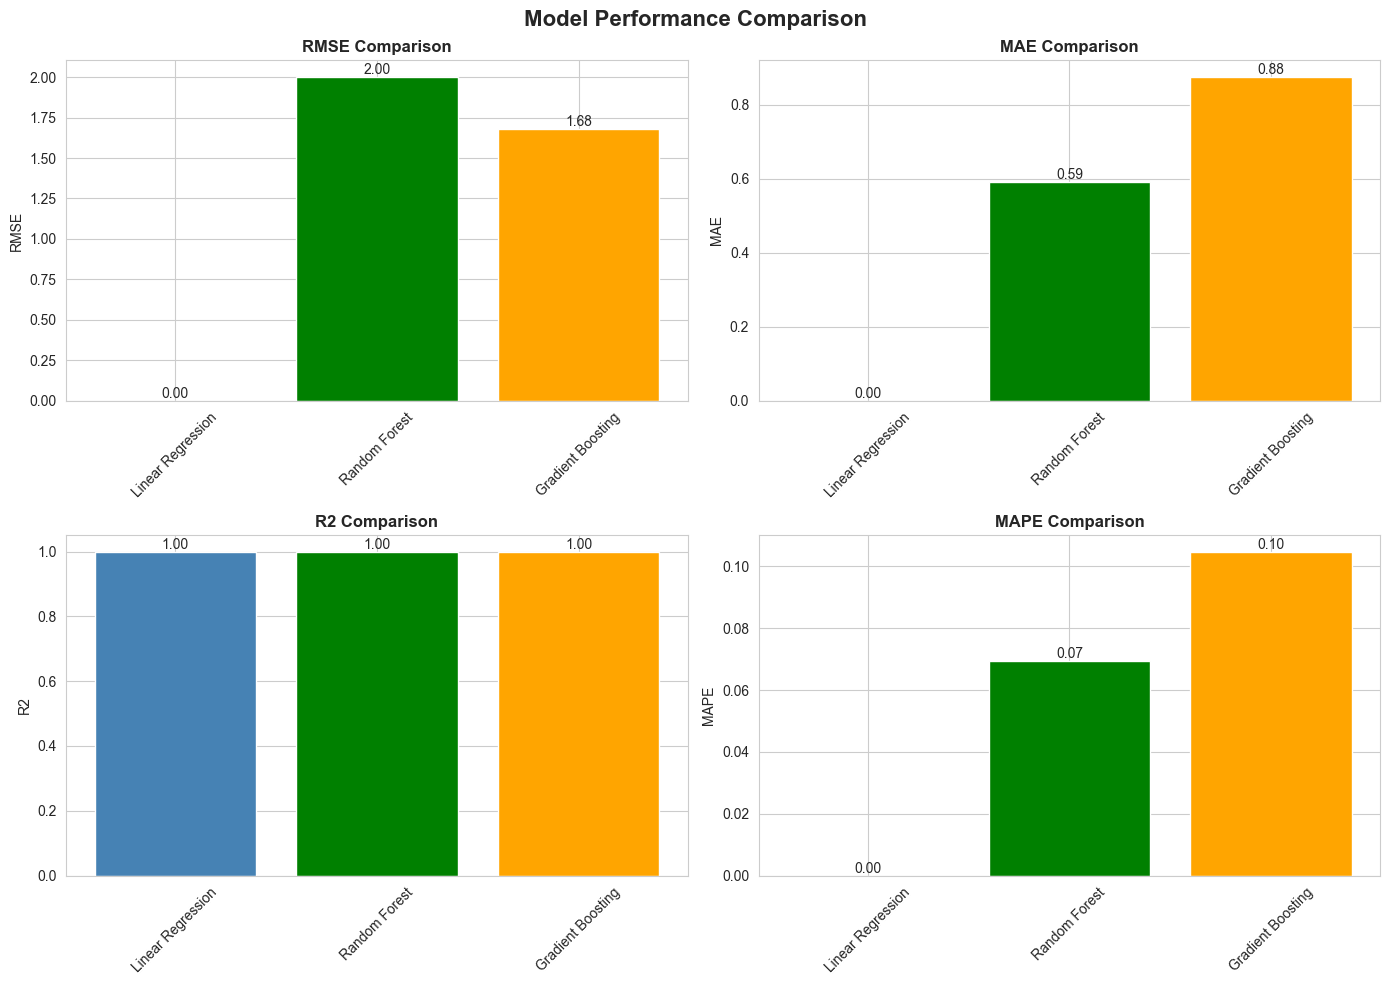

In [32]:
# Figure 7: Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Performance Comparison", fontsize=16, fontweight="bold")

metrics = ["RMSE", "MAE", "R2", "MAPE"]
for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    values = [results[model][metric] for model in models.keys()]
    bars = axes[row, col].bar(
        models.keys(), values, color=["steelblue", "green", "orange"]
    )
    axes[row, col].set_title(f"{metric} Comparison", fontweight="bold")
    axes[row, col].set_ylabel(metric)
    axes[row, col].tick_params(axis="x", rotation=45)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[row, col].text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
        )

plt.tight_layout()



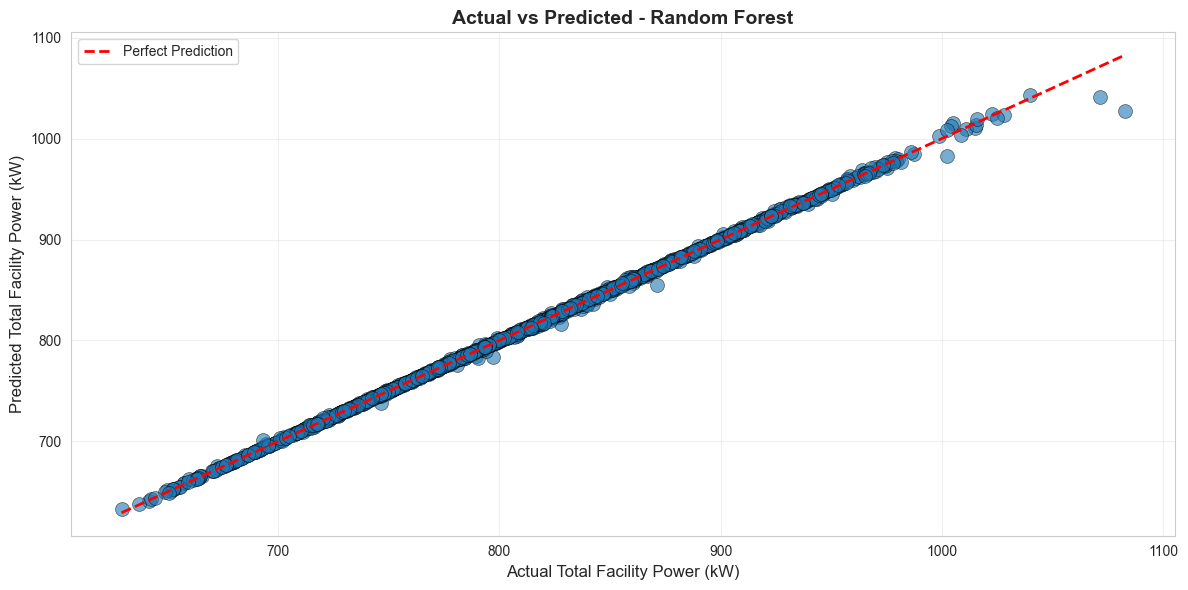

In [33]:
# Figure 8: Actual vs Predicted for Best Model
plt.figure(figsize=(12, 6))
plt.scatter(
    y_test, best_predictions, alpha=0.6, s=100, edgecolors="black", linewidths=0.5
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)
plt.xlabel("Actual Total Facility Power (kW)", fontsize=12)
plt.ylabel("Predicted Total Facility Power (kW)", fontsize=12)
plt.title(f"Actual vs Predicted - {best_model_name}", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()



### The model seems to be overfitting (when the model learns its training data too well, capturing noise and specific details, causing it to perform excellently on that data but poorly on new, unseen data because it fails to generalize).

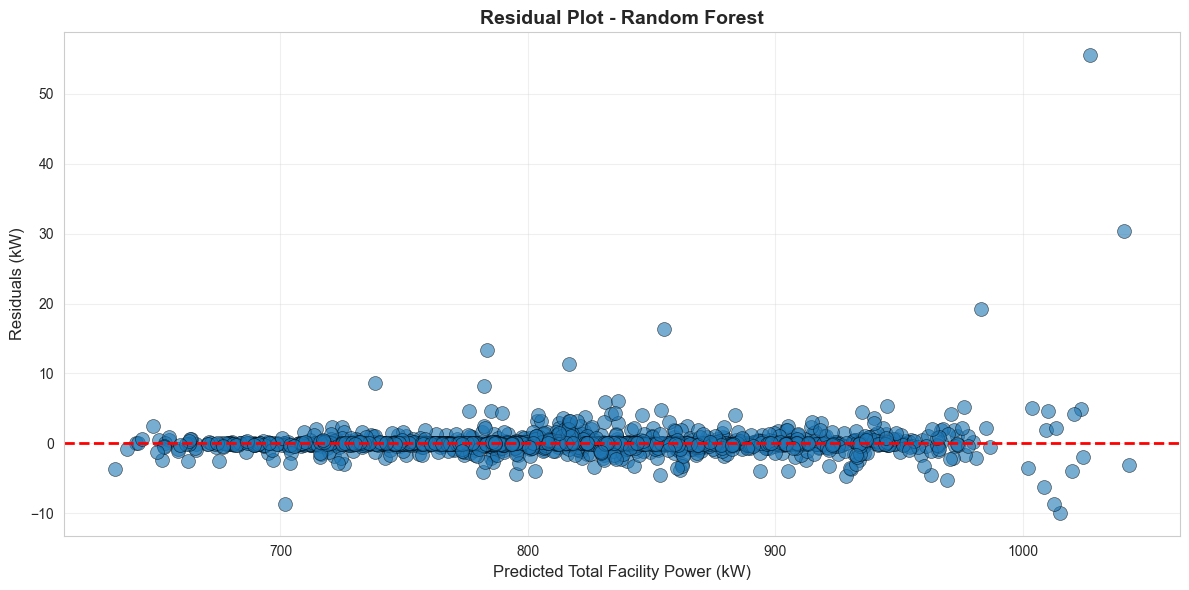

In [34]:
# Figure 9: Residual Plot
residuals = y_test - best_predictions
plt.figure(figsize=(12, 6))
plt.scatter(
    best_predictions, residuals, alpha=0.6, s=100, edgecolors="black", linewidths=0.5
)
plt.axhline(y=0, color="r", linestyle="--", lw=2)
plt.xlabel("Predicted Total Facility Power (kW)", fontsize=12)
plt.ylabel("Residuals (kW)", fontsize=12)
plt.title(f"Residual Plot - {best_model_name}", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()



### Summary of Model Health: Overall, this is a strong plot. Most of your errors (residuals) are between -5 and +5 kW, which is quite small compared to a total load of 800+ kW. This indicates a high level of precision for the majority of your data


--------------------------------------------------------------------------------
FEATURE IMPORTANCE RANKING
--------------------------------------------------------------------------------
            feature  importance
        it_power_kw    0.865921
   cooling_power_kw    0.133547
     outside_temp_c    0.000239
avg_cpu_utilization    0.000119
     active_servers    0.000106
               hour    0.000041
        day_of_week    0.000024
         is_weekend    0.000002


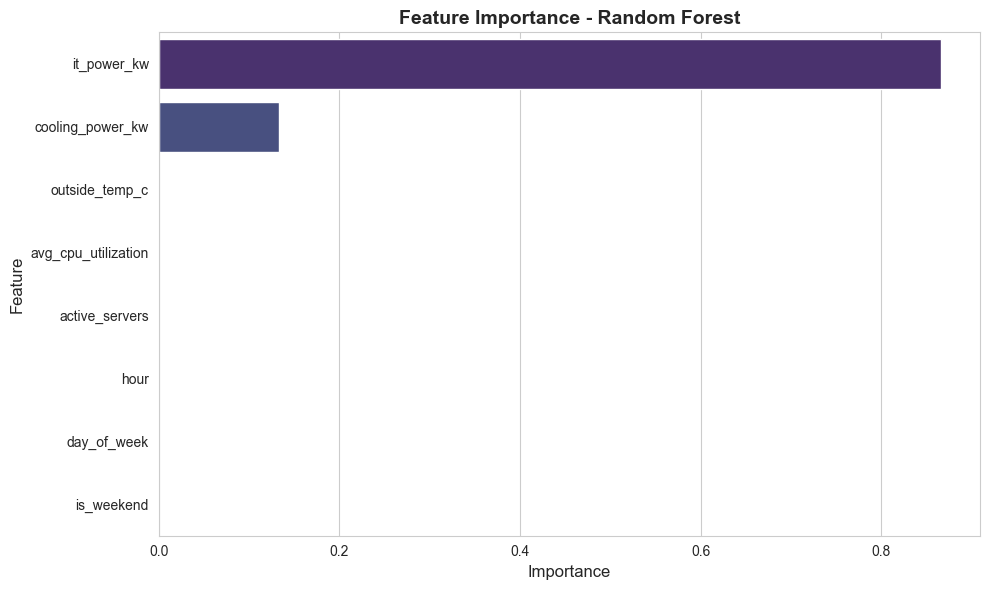

In [35]:
# Figure 10: Feature Importance (for Random Forest)
if best_model_name in ["Random Forest", "Gradient Boosting"]:
    feature_importance = pd.DataFrame(
        {"feature": feature_cols, "importance": best_model.feature_importances_}
    ).sort_values("importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x="importance", y="feature", palette="viridis")
    plt.title(f"Feature Importance - {best_model_name}", fontsize=14, fontweight="bold")
    plt.xlabel("Importance", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.tight_layout()

    print("\n" + "-" * 80)
    print("FEATURE IMPORTANCE RANKING")
    print("-" * 80)
    print(feature_importance.to_string(index=False))


### Feature importance of it_power_kw is very high in contradiction to the other features.

In [40]:
# ============================================================================
# 4. SAVE THE BEST MODEL AND SCALER
# ============================================================================
print("\n" + "="*80)
print("5. SAVING MODEL AND ARTIFACTS")
print("="*80)

# Save the best model
model_filename = f'datacenter_energy_forecasting_model.pkl'
joblib.dump(best_model, model_filename)
print(f"\n✓ {model_filename}")

# Save feature names for future use
feature_info = {
    'feature_columns': feature_cols,
    'best_model_name': best_model_name,
    'model_metrics': {
        'RMSE': results[best_model_name]['RMSE'],
        'MAE': results[best_model_name]['MAE'],
        'R2': results[best_model_name]['R2'],
        'MAPE': results[best_model_name]['MAPE']
    }
}
joblib.dump(feature_info, 'model_info.pkl')
print(f"✓ Saved model info: model_info.pkl")



5. SAVING MODEL AND ARTIFACTS

✓ datacenter_energy_forecasting_model.pkl
✓ Saved model info: model_info.pkl


In [ ]:
# ============================================================================
# 5. SUMMARY AND RECOMMENDATIONS
# ============================================================================
print("\n" + "=" * 80)
print("4. SUMMARY AND RECOMMENDATIONS")
print("=" * 80)

print(
    f"""
Key Findings:
1.Linear Regression: The "Perfect" FitPerformance: Achieved a mathematically perfect score ($R^2 = 1.0000$, $RMSE = 0.00$).
Verdict: This is highly unusual in real-world energy data. It suggests data leakage, meaning your features likely include a variable 
that is a direct component of the total power (like a sub-meter sum).

2. Gradient Boosting: The Balanced PerformerPerformance: Nearly perfect ($R^2 = 0.9995$) with the lowest RMSE (1.68 kW).
Verdict: This model is the best at handling "tough" data points and minimizing large errors. It is likely the most robust model for capturing the complex,
non-linear patterns of facility power usage.

3. Random Forest: The High-Precision ToolPerformance: Exceptional accuracy ($R^2 = 0.9993$) with the lowest MAE (0.59 kW).
Verdict: On average, this model gets closer to the "truth" than the others. However, as seen in your residual plot, 
it struggles slightly more with peak values (higher $RMSE$) compared to Gradient Boosting.

4. Best performing model: {best_model_name}
   - RMSE: {results[best_model_name]['RMSE']:.2f} kW
   - R² Score: {results[best_model_name]['R2']:.4f}
   - MAPE: {results[best_model_name]['MAPE']:.2f}%
"""
)

print("=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)


4. SUMMARY AND RECOMMENDATIONS

Key Findings:
1.Linear Regression: The "Perfect" FitPerformance: Achieved a mathematically perfect score ($R^2 = 1.0000$, $RMSE = 0.00$).
Verdict: This is highly unusual in real-world energy data. It suggests data leakage, meaning your features likely include a variable 
that is a direct component of the total power (like a sub-meter sum).

2. Gradient Boosting: The Balanced PerformerPerformance: Nearly perfect ($R^2 = 0.9995$) with the lowest RMSE (1.68 kW).
Verdict: This model is the best at handling "tough" data points and minimizing large errors. It is likely the most robust model for capturing the complex,
non-linear patterns of facility power usage.

3. Random Forest: The High-Precision ToolPerformance: Exceptional accuracy ($R^2 = 0.9993$) with the lowest MAE (0.59 kW).
Verdict: On average, this model gets closer to the "truth" than the others. However, as seen in your residual plot, 
it struggles slightly more with peak values (higher $RMSE$) co